# **⏬Importing Data**

In [ ]:
# reading data
import numpy as np
import pandas as pd

df = pd.read_csv("/content/Carbon Emission.csv")
df.head()

,Body Type,Sex,Diet,How Often Shower,Heating Energy Source,Transport,Vehicle Type,Social Activity,Monthly Grocery Bill,Frequency of Traveling by Air,Vehicle Monthly Distance Km,Waste Bag Size,Waste Bag Weekly Count,How Long TV PC Daily Hour,How Many New Clothes Monthly,How Long Internet Daily Hour,Energy efficiency,Recycling,Cooking_With,CarbonEmission
0,overweight,female,pescatarian,daily,coal,public,NaN,often,230,frequently,210,large,4,7,26,1,No,['Metal'],"['Stove', 'Oven']",2238
1,obese,female,vegetarian,less frequently,natural gas,walk/bicycle,NaN,often,114,rarely,9,extra large,3,9,38,5,No,['Metal'],"['Stove', 'Microwave']",1892
2,overweight,male,omnivore,more frequently,wood,private,petrol,never,138,never,2472,small,1,14,47,6,Sometimes,['Metal'],"['Oven', 'Microwave']",2595
3,overweight,male,omnivore,twice a day,wood,walk/bicycle,NaN,sometimes,157,rarely,74,medium,3,20,5,7,Sometimes,"['Paper', 'Plastic', 'Glass', 'Metal']","['Microwave', 'Grill', 'Airfryer']",1074
4,obese,female,vegetarian,daily,coal,private,diesel,often,266,very frequently,8457,large,1,3,5,6,Yes,['Paper'],['Oven'],4743


# **👁Viewing Data**

In [ ]:
# getting dataframe shape
df.shape

(10000, 20)

In [ ]:
# getting stats of numerical data
df.describe()

,Monthly Grocery Bill,Vehicle Monthly Distance Km,Waste Bag Weekly Count,How Long TV PC Daily Hour,How Many New Clothes Monthly,How Long Internet Daily Hour,CarbonEmission
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,173.875200,2031.485900,4.024600,12.139200,25.109000,11.889100,2269.147300
std,72.234018,2769.715597,1.990375,7.106369,14.698725,7.277218,1017.675247
min,50.000000,0.000000,1.000000,0.000000,0.000000,0.000000,306.000000
25%,111.000000,69.000000,2.000000,6.000000,13.000000,6.000000,1538.000000
50%,173.000000,823.000000,4.000000,12.000000,25.000000,12.000000,2080.000000
75%,237.000000,2516.750000,6.000000,18.000000,38.000000,18.000000,2768.000000
max,299.000000,9999.000000,7.000000,24.000000,50.000000,24.000000,8377.000000


In [ ]:
# renaming columns
df.columns = ['Body Type', 'Sex', 'Diet', 'Shower', 'Heating', 'Transport', 'Vehicle', 'Social', 'Grocery', 'Flight', 'Vehicle Distance',
              'Bag Size', 'Waste Weekly', 'TV Daily Hour', 'Clothes Monthly', 'Internet Daily', 'Energy Eff', 'Recycling', 'Cooking',
              'CarbonEmission']
df.head()

,Body Type,Sex,Diet,Shower,Heating,Transport,Vehicle,Social,Grocery,Flight,Vehicle Distance,Bag Size,Waste Weekly,TV Daily Hour,Clothes Monthly,Internet Daily,Energy Eff,Recycling,Cooking,CarbonEmission
0,overweight,female,pescatarian,daily,coal,public,NaN,often,230,frequently,210,large,4,7,26,1,No,['Metal'],"['Stove', 'Oven']",2238
1,obese,female,vegetarian,less frequently,natural gas,walk/bicycle,NaN,often,114,rarely,9,extra large,3,9,38,5,No,['Metal'],"['Stove', 'Microwave']",1892
2,overweight,male,omnivore,more frequently,wood,private,petrol,never,138,never,2472,small,1,14,47,6,Sometimes,['Metal'],"['Oven', 'Microwave']",2595
3,overweight,male,omnivore,twice a day,wood,walk/bicycle,NaN,sometimes,157,rarely,74,medium,3,20,5,7,Sometimes,"['Paper', 'Plastic', 'Glass', 'Metal']","['Microwave', 'Grill', 'Airfryer']",1074
4,obese,female,vegetarian,daily,coal,private,diesel,often,266,very frequently,8457,large,1,3,5,6,Yes,['Paper'],['Oven'],4743


# **🧹Data Cleaning**

In [ ]:
# checking for null values
df.isna().sum()

,0
Body Type,0
Sex,0
Diet,0
Shower,0
Heating,0
Transport,0
Vehicle,6721
Social,0
Grocery,0
Flight,0


In [ ]:
# handling null values
df.replace(np.nan, 'None', inplace=True)
df.head()

,Body Type,Sex,Diet,Shower,Heating,Transport,Vehicle,Social,Grocery,Flight,Vehicle Distance,Bag Size,Waste Weekly,TV Daily Hour,Clothes Monthly,Internet Daily,Energy Eff,Recycling,Cooking,CarbonEmission
0,overweight,female,pescatarian,daily,coal,public,None,often,230,frequently,210,large,4,7,26,1,No,['Metal'],"['Stove', 'Oven']",2238
1,obese,female,vegetarian,less frequently,natural gas,walk/bicycle,None,often,114,rarely,9,extra large,3,9,38,5,No,['Metal'],"['Stove', 'Microwave']",1892
2,overweight,male,omnivore,more frequently,wood,private,petrol,never,138,never,2472,small,1,14,47,6,Sometimes,['Metal'],"['Oven', 'Microwave']",2595
3,overweight,male,omnivore,twice a day,wood,walk/bicycle,None,sometimes,157,rarely,74,medium,3,20,5,7,Sometimes,"['Paper', 'Plastic', 'Glass', 'Metal']","['Microwave', 'Grill', 'Airfryer']",1074
4,obese,female,vegetarian,daily,coal,private,diesel,often,266,very frequently,8457,large,1,3,5,6,Yes,['Paper'],['Oven'],4743


# **🧶Feature Engineering**

## **🧵Expanding `Recycling` and `Cooking` features**

In [ ]:
import ast

df['Recycling'] = df['Recycling'].apply(ast.literal_eval)
recycling_items = list(set(item for sublist in df['Recycling'] for item in sublist))

df['Cooking'] = df['Cooking'].apply(ast.literal_eval)
cooking_items = list(set(item for sublist in df['Cooking'] for item in sublist))

# Create columns for recycling
for item in recycling_items:
    df[item] = df['Recycling'].apply(lambda x: 1 if item in x else 0)

# Create columns for cooking
for item in cooking_items:
    df[item] = df['Cooking'].apply(lambda x: 1 if item in x else 0)

df = df.drop(columns=['Recycling', 'Cooking'])
df.head()

,Body Type,Sex,Diet,Shower,Heating,Transport,Vehicle,Social,Grocery,Flight,...,CarbonEmission,Plastic,Metal,Paper,Glass,Grill,Airfryer,Stove,Oven,Microwave
0,overweight,female,pescatarian,daily,coal,public,None,often,230,frequently,...,2238,0,1,0,0,0,0,1,1,0
1,obese,female,vegetarian,less frequently,natural gas,walk/bicycle,None,often,114,rarely,...,1892,0,1,0,0,0,0,1,0,1
2,overweight,male,omnivore,more frequently,wood,private,petrol,never,138,never,...,2595,0,1,0,0,0,0,0,1,1
3,overweight,male,omnivore,twice a day,wood,walk/bicycle,None,sometimes,157,rarely,...,1074,1,1,1,1,1,1,0,0,1
4,obese,female,vegetarian,daily,coal,private,diesel,often,266,very frequently,...,4743,0,0,1,0,0,0,0,1,0


In [ ]:
# restructuring features
df = df[['Body Type', 'Sex', 'Diet', 'Shower', 'Heating', 'Transport', 'Vehicle', 'Social', 'Grocery', 'Flight', 'Vehicle Distance', 'Bag Size',
         'Waste Weekly', 'TV Daily Hour', 'Clothes Monthly', 'Internet Daily', 'Energy Eff', 'Plastic', 'Glass', 'Metal', 'Paper', 'Microwave',
         'Oven', 'Stove', 'Airfryer', 'Grill', 'CarbonEmission']]

df.head()

,Body Type,Sex,Diet,Shower,Heating,Transport,Vehicle,Social,Grocery,Flight,...,Plastic,Glass,Metal,Paper,Microwave,Oven,Stove,Airfryer,Grill,CarbonEmission
0,overweight,female,pescatarian,daily,coal,public,None,often,230,frequently,...,0,0,1,0,0,1,1,0,0,2238
1,obese,female,vegetarian,less frequently,natural gas,walk/bicycle,None,often,114,rarely,...,0,0,1,0,1,0,1,0,0,1892
2,overweight,male,omnivore,more frequently,wood,private,petrol,never,138,never,...,0,0,1,0,1,1,0,0,0,2595
3,overweight,male,omnivore,twice a day,wood,walk/bicycle,None,sometimes,157,rarely,...,1,1,1,1,1,0,0,1,1,1074
4,obese,female,vegetarian,daily,coal,private,diesel,often,266,very frequently,...,0,0,0,1,0,1,0,0,0,4743


In [ ]:
# defining numerical and categorical columns
cat_col = ['Body Type', 'Sex', 'Diet', 'Shower', 'Heating', 'Transport', 'Vehicle', 'Social','Flight', 'Bag Size',
           'Energy Eff', 'Plastic', 'Glass', 'Metal', 'Paper', 'Microwave', 'Oven', 'Stove', 'Airfryer', 'Grill']
num_col = ['Grocery', 'Vehicle Distance', 'Waste Weekly', 'TV Daily Hour', 'Internet Daily', 'Clothes Monthly']

# **🎍Data Preprocessing**

## **⚾Encoding Categorical Values**

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in cat_col:
    encoder = LabelEncoder()
    df[col] = encoder.fit_transform(df[col])
    encoders[col] = encoder

df.head()

,Body Type,Sex,Diet,Shower,Heating,Transport,Vehicle,Social,Grocery,Flight,...,Plastic,Glass,Metal,Paper,Microwave,Oven,Stove,Airfryer,Grill,CarbonEmission
0,2,0,1,0,0,1,0,1,0.777025,0,...,0,0,1,0,0,1,1,0,0,2238
1,1,0,3,1,2,2,0,1,-0.828947,2,...,0,0,1,0,1,0,1,0,0,1892
2,2,1,0,2,3,0,5,0,-0.496677,1,...,0,0,1,0,1,1,0,0,0,2595
3,2,1,0,3,3,2,0,2,-0.233630,2,...,1,1,1,1,1,0,0,1,1,1074
4,1,0,3,0,0,0,1,1,1.275430,3,...,0,0,0,1,0,1,0,0,0,4743


## **🥎Scaling Numerical Values**

In [ ]:
from sklearn.preprocessing import StandardScaler

scalers = {}

for column in num_col:
    scaler = StandardScaler()
    df[column] = scaler.fit_transform(df[[column]])
    scalers[column] = scaler

df.head()

,Body Type,Sex,Diet,Shower,Heating,Transport,Vehicle,Social,Grocery,Flight,...,Plastic,Glass,Metal,Paper,Microwave,Oven,Stove,Airfryer,Grill,CarbonEmission
0,2,0,1,0,0,1,0,1,0.777025,0,...,0,0,1,0,0,1,1,0,0,2238
1,1,0,3,1,2,2,0,1,-0.828947,2,...,0,0,1,0,1,0,1,0,0,1892
2,2,1,0,2,3,0,5,0,-0.496677,1,...,0,0,1,0,1,1,0,0,0,2595
3,2,1,0,3,3,2,0,2,-0.233630,2,...,1,1,1,1,1,0,0,1,1,1074
4,1,0,3,0,0,0,1,1,1.275430,3,...,0,0,0,1,0,1,0,0,0,4743


## **💎Defining `Feature` and `Target` Variables**

In [ ]:
# selecting features and target
X = df.drop('CarbonEmission', axis=1)
y = df['CarbonEmission']

## **🎃Train Test Split**

In [ ]:
# splitting data into train and test data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **🤖ML Modelling**

## **🧨XGBoost Regressor**

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

xgb_model = xgb.XGBRegressor()
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f'XGBoost Regressor Results:')
print(f'Mean Absolute Error: {mae_xgb}')
print(f'Mean Squared Error: {mse_xgb}')
print(f'Root Mean Squared Error: {rmse_xgb}')
print(f'R-squared: {r2_xgb}')

XGBoost Regressor Results:
Mean Absolute Error: 125.84233093261719
Mean Squared Error: 29724.603515625
Root Mean Squared Error: 172.40824665782375
R-squared: 0.9714106321334839


## **🎞Gradient Boosting Regressor**

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_model = GradientBoostingRegressor()
gbr_model.fit(X_train, y_train)
y_pred_gbr = gbr_model.predict(X_test)

mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
mse_gbr = mean_squared_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mse_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)

print(f'Gradient Boosting Regressor Results:')
print(f'Mean Absolute Error: {mae_gbr}')
print(f'Mean Squared Error: {mse_gbr}')
print(f'Root Mean Squared Error: {rmse_gbr}')
print(f'R-squared: {r2_gbr}')

Gradient Boosting Regressor Results:
Mean Absolute Error: 167.14104714280015
Mean Squared Error: 53250.76039187876
Root Mean Squared Error: 230.7612627627929
R-squared: 0.948782981907977


## **🥽Random Forest Regressor**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rfr_model = RandomForestRegressor()
rfr_model.fit(X_train, y_train)
y_pred = rfr_model.predict(X_test)

mae_rfr = mean_absolute_error(y_test, y_pred)
mse_rfr = mean_squared_error(y_test, y_pred)
rmse_rfr = np.sqrt(mse_rfr)
r2_rfr = r2_score(y_test, y_pred)

print(f'Mean Absolute Error: {mae_rfr}')
print(f'Mean Squared Error: {mse_rfr}')
print(f'Root Mean Squared Error: {rmse_rfr}')
print(f'R-squared: {r2_rfr}')

Mean Absolute Error: 227.7487
Mean Squared Error: 93070.97485069999
Root Mean Squared Error: 305.0753592978299
R-squared: 0.9104835730477663


In [ ]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.8 MB/s eta 0:00:00


## **🧿Cat Boost Regressor**

In [ ]:
import catboost as cb

catboost_model = cb.CatBoostRegressor(
    iterations=1000,
    learning_rate=0.1,
    depth=5,
    eval_metric='RMSE',
    cat_features=[0, 1, 2, 3, 4, 5, 6],
    verbose=100
)

catboost_model.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=100)
y_pred_catboost = catboost_model.predict(X_test)

mae_catboost = mean_absolute_error(y_test, y_pred_catboost)
mse_catboost = mean_squared_error(y_test, y_pred_catboost)
rmse_catboost = np.sqrt(mse_catboost)
r2_catboost = r2_score(y_test, y_pred_catboost)

print(f'CatBoost Regressor Results:')
print(f'Mean Absolute Error: {mae_catboost}')
print(f'Mean Squared Error: {mse_catboost}')
print(f'Root Mean Squared Error: {rmse_catboost}')
print(f'R-squared: {r2_catboost}')

0:	learn: 946.5372603	test: 949.8866335	best: 949.8866335 (0)	total: 13.3ms	remaining: 13.3s
100:	learn: 205.1339539	test: 194.4772123	best: 194.4772123 (100)	total: 1.04s	remaining: 9.29s
200:	learn: 145.8198542	test: 137.2825569	best: 137.2825569 (200)	total: 2.09s	remaining: 8.32s
300:	learn: 121.2761153	test: 118.2314344	best: 118.2314344 (300)	total: 3.17s	remaining: 7.37s
400:	learn: 108.6058509	test: 111.9301788	best: 111.8389705 (395)	total: 4.45s	remaining: 6.65s
500:	learn: 100.7244514	test: 106.3503837	best: 106.3503837 (500)	total: 6.64s	remaining: 6.62s
600:	learn: 94.2567343	test: 104.7399733	best: 104.6810378 (596)	total: 7.72s	remaining: 5.13s
700:	learn: 88.6448367	test: 101.3029259	best: 101.3029259 (700)	total: 8.72s	remaining: 3.72s
800:	learn: 84.8416011	test: 100.0537019	best: 100.0532697 (796)	total: 9.74s	remaining: 2.42s
900:	learn: 81.7213907	test: 99.1434523	best: 99.1434523 (900)	total: 10.8s	remaining: 1.18s
999:	learn: 79.1097101	test: 98.4591380	best: 98.

In [ ]:
model_r2 = {
    'XG Boost Regression' : r2_xgb,
    'Catboost Regression' : r2_catboost,
    'Gradient Boost Regression' : r2_gbr,
    'Random Forest Regression' : r2_rfr,
}

model_rmse = {
    'XG Boost Regression' : rmse_xgb,
    'Catboost Regression' : rmse_catboost,
    'Gradient Boost Regression' : rmse_gbr,
    'Random Forest Regression' : rmse_rfr,
}

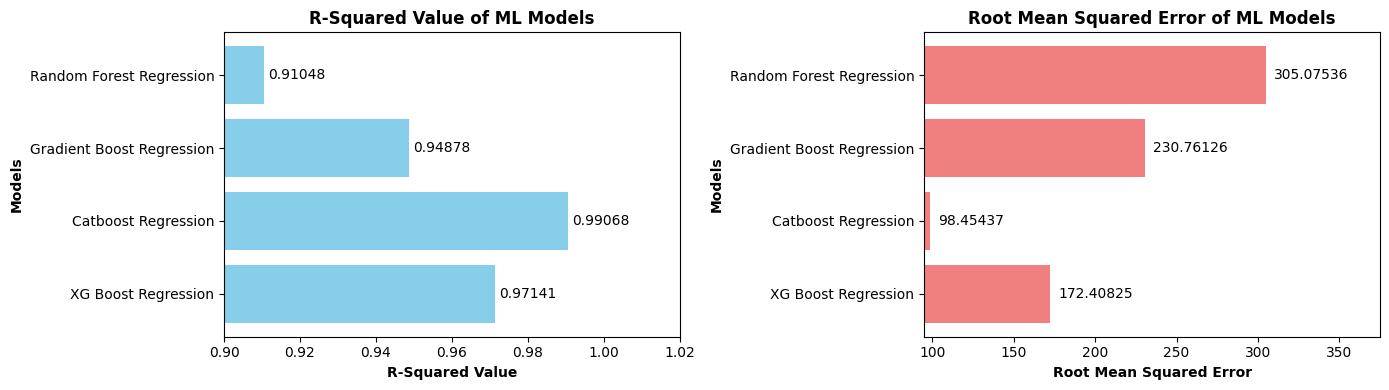

In [ ]:
# Create a figure with two subplots
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Plot MAE
bars_r2 = ax1.barh(list(model_r2.keys()), list(model_r2.values()), color='skyblue')
ax1.set_ylabel('Models', fontweight='bold')
ax1.set_xlabel('R-Squared Value', fontweight='bold')
ax1.set_title('R-Squared Value of ML Models', fontweight='bold')
ax1.set_xlim(0.9, 1.02)
for bar in bars_r2:
    width = bar.get_width()
    ax1.text(width + 0.001, bar.get_y() + bar.get_height()/2, '{:.5f}'.format(round(width, 5)), ha='left', va='center')

# Plot RMSE
bars_rmse = ax2.barh(list(model_rmse.keys()), list(model_rmse.values()), color='lightcoral')
ax2.set_ylabel('Models', fontweight='bold')
ax2.set_xlabel('Root Mean Squared Error', fontweight='bold')
ax2.set_title('Root Mean Squared Error of ML Models', fontweight='bold')
ax2.set_xlim(95, 375)
for bar in bars_rmse:
    width = bar.get_width()
    ax2.text(width + 5, bar.get_y() + bar.get_height()/2, '{:.5f}'.format(round(width, 5)), ha='left', va='center')

plt.tight_layout()
plt.show()

Thus, **`CatBoost Regressor`** performs th best out of all!

In [ ]:
import joblib

# Save CatBoost model
catboost_model.save_model("catboost_carbon_model.cbm")

# Save scaler (VERY IMPORTANT)
joblib.dump(scalers, "scalers.pkl")

# Save feature names in correct order
joblib.dump(X_train.columns.tolist(), "feature_names.pkl")

joblib.dump(encoders, "label_encoders.pkl")

print("✅ Model, scaler, and feature names saved")



✅ Model, scaler, and feature names saved
